In [3]:
#   Import Matplotlib, pandas, and plotly
import pandas as pd 
import plotly as ply
import matplotlib.pyplot as plt
import plotly.express as px

Prepare Data

In [4]:
df1 = pd.read_csv("data/brasil-real-estate-1.csv")
df1.head()

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"


In [5]:
#Drop all rows with NaN values from the DataFrame df1.
df1.dropna(inplace=True)

In [6]:
#Use the "lat-lon" column to create two separate columns in df1: "lat" and "lon". Make sure that the data type for these new columns is float.
df1[["lat", "lon"]] = df1["lat-lon"].str.split(',',expand=True)
# change lat and lon from type object(string) to type float
df1["lat"]=df1.lat.astype(float)
df1["lon"]=df1.lon.astype(float)


In [7]:
#Use the "place_with_parent_names" column to create a "state" column for df1. 
df1["state"]= df1["place_with_parent_names"].str.split("|", expand= True)[2]

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11551 entries, 0 to 12833
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            11551 non-null  object 
 1   place_with_parent_names  11551 non-null  object 
 2   region                   11551 non-null  object 
 3   lat-lon                  11551 non-null  object 
 4   area_m2                  11551 non-null  float64
 5   price_usd                11551 non-null  object 
 6   lat                      11551 non-null  float64
 7   lon                      11551 non-null  float64
 8   state                    11551 non-null  object 
dtypes: float64(3), object(6)
memory usage: 902.4+ KB


In [9]:
#Transform the "price_usd" column of df1 so that all values are floating-point numbers instead of strings
df1["price_usd"]=df1['price_usd'].str.replace("$","", regex=False).str.replace(",","", regex=False).astype(float)


In [10]:
#Drop the "lat-lon" and "place_with_parent_names" columns from df1.
df1= df1.drop(["lat-lon","place_with_parent_names"], axis=1)

In [11]:
#Import the CSV file brasil-real-estate-2.csv into the DataFrame df2.
df2=pd.read_csv("data/brasil-real-estate-2.csv")

In [12]:
df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36


In [13]:
#Use the "price_brl" column to create a new column named "price_usd". When this data was collected in 2015 and 2016, a US dollar cost 3.19 Brazilian reals.
df2["price_usd"]=df2["price_brl"]/3.19


In [14]:
#Drop the "price_brl" column from df2, as well as any rows that have NaN values.
df2.dropna(inplace=True)
df2= df2.drop(["price_brl"], axis=1)

In [15]:
#Concatenate df1 and df2 to create a new DataFrame named df.
df= pd.concat([df1,df2])
print("df shape:", df.shape)

df shape: (22844, 7)


In [16]:
summary_stats =df[["area_m2", "price_usd"]].describe()
summary_stats


,area_m2,price_usd
count,22844.000000,22844.000000
mean,115.020224,194987.315480
std,47.742932,103617.682978
min,53.000000,74892.340000
25%,76.000000,113898.770000
50%,103.000000,165697.555000
75%,142.000000,246900.880878
max,252.000000,525659.717868


In [17]:
# Use plotly express to create figure
import plotly.io as pio
pio.renderers.default = "iframe"
# 1. Modern function: scatter_map
fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    center={"lat": -14.2, "lon": -51.9},
    zoom=3, # Added zoom for better visibility
    width=600,
    height=600,
    hover_data=["price_usd"]
)

# 2. Modern style setting
fig.update_layout(map_style="open-street-map")

fig.show()

In [18]:
#Use the describe method to create a DataFrame summary_stats with the summary statistics for the "area_m2" and "price_usd" columns.
summary_stats = df[["area_m2", "price_usd"]].describe()
summary_stats

,area_m2,price_usd
count,22844.000000,22844.000000
mean,115.020224,194987.315480
std,47.742932,103617.682978
min,53.000000,74892.340000
25%,76.000000,113898.770000
50%,103.000000,165697.555000
75%,142.000000,246900.880878
max,252.000000,525659.717868


Text(0.5, 1.0, 'Distribution of Home Prices')

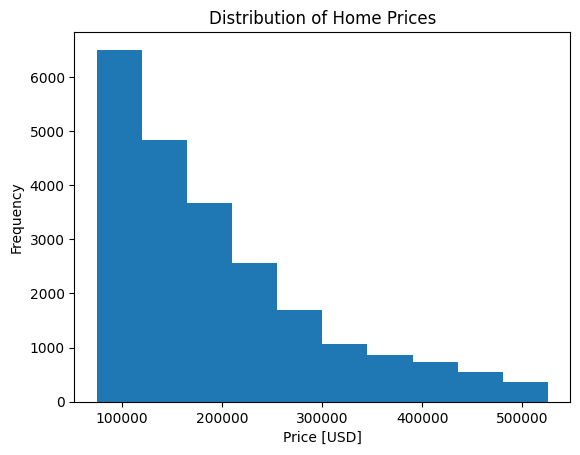

In [20]:
fig, ax = plt.subplots()


ax.hist(df["price_usd"])
plt.xlabel("Price [USD]")
plt.ylabel("Frequency")
plt.title("Distribution of Home Prices")

Text(0.5, 1.0, 'Distribution of Home Sizes')

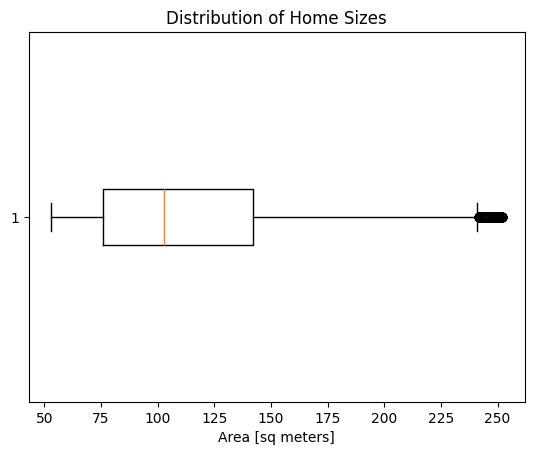

In [22]:
#Create a horizontal boxplot of "area_m2".
fig, ax = plt.subplots()

#Build box plot
ax.boxplot(df["area_m2"], vert=False)

# Label x-axis
plt.xlabel("Area [sq meters]")
# Add title
plt.title("Distribution of Home Sizes")


In [25]:
mean_price_by_region= df.groupby("region")["price_usd"].mean().sort_values(ascending=True)

mean_price_by_region.head()

region
Central-West    178596.283663
North           181308.958207
Northeast       185422.985441
South           189012.345265
Southeast       208996.762778
Name: price_usd, dtype: float64

<Axes: title={'center': 'Mean Home Price by Region'}, xlabel='Region', ylabel='Mean Price [USD]'>

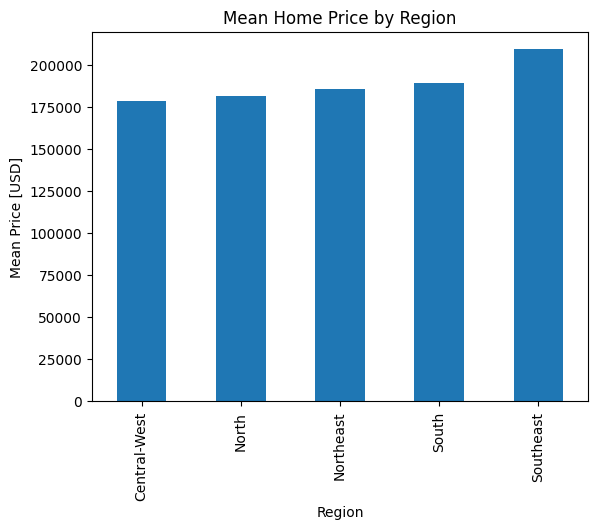

In [27]:
# Build bar chart, label axes, add title using pandas plots

mean_price_by_region.plot(
    kind="bar",
    xlabel="Region",
    ylabel="Mean Price [USD]",
    title="Mean Home Price by Region"
)

Now we are going to shift our focus to the southern region of Brazil, and look at the relationship between home size and price.


In [31]:
#Create a DataFrame df_south that contains all the homes from df that are in the "South" region.

df_south = df[df["region"]=="South"]
df_south.head()

,property_type,region,area_m2,price_usd,lat,lon,state
9304,apartment,South,127.0,296448.85,-25.455704,-49.292918,Paraná
9305,apartment,South,104.0,219996.25,-25.455704,-49.292918,Paraná
9306,apartment,South,100.0,194210.50,-25.460236,-49.293812,Paraná
9307,apartment,South,77.0,149252.94,-25.460236,-49.293812,Paraná
9308,apartment,South,73.0,144167.75,-25.460236,-49.293812,Paraná


In [34]:
#create a Series homes_by_state that contains the number of properties in each state in df_south.
homes_by_state =df_south["state"].value_counts()
homes_by_state

state
Rio Grande do Sul    2643
Santa Catarina       2634
Paraná               2544
Name: count, dtype: int64

Text(0.5, 1.0, 'Rio Grande do Sul: Price vs. Area')

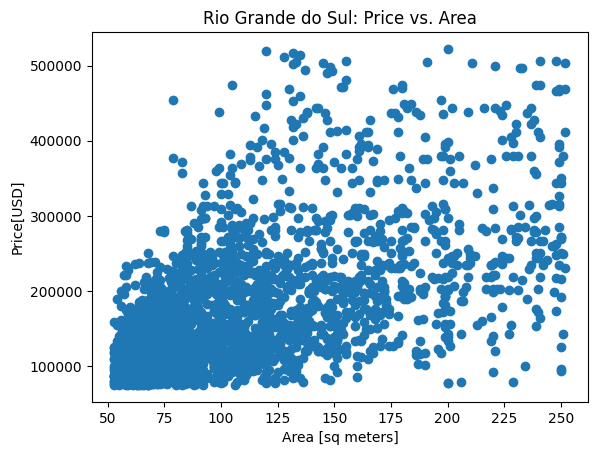

In [41]:
# Subset data
df_south_rgs = df[df["state"] == "Rio Grande do Sul"]

# Build scatter plot
fig, ax = plt.subplots()
ax.scatter(x=df_south_rgs["area_m2"] , y=df_south_rgs["price_usd"])


# Label axes
plt.xlabel("Area [sq meters]")
plt.ylabel("Price[USD]")
# Add title
plt.title("Rio Grande do Sul: Price vs. Area")

In [ ]:
#dictionary south_states_corr, where the keys are the names of the three states in the "South" region of Brazil, and their associated values are the correlation coefficient between "area_m2" and "price_usd" in that state.
south_states_corr = {
state: df_south[df_south["state"] == state][["area_m2", "price_usd"]].corr().iloc[0,1]
for state in df_south["state"].unique()
}
south_states_corr

{'Paraná': np.float64(0.5436659935502652),
 'Rio Grande do Sul': np.float64(0.577326743371769),
 'Santa Catarina': np.float64(0.5068121776366797)}

In [52]:
# Look at the 'region' column for rows where 'state' is Espírito Santo
region_value = df[df["state"] == "Minas Gerais"]["region"]
print(region_value)

6304    Southeast
6305    Southeast
6306    Southeast
6307    Southeast
6308    Southeast
          ...    
9299    Southeast
9300    Southeast
9301    Southeast
9302    Southeast
9303    Southeast
Name: region, Length: 2680, dtype: object


In [56]:
df_Southeast= df[df["region"]=="Southeast"]
df_Southeast

,property_type,region,area_m2,price_usd,lat,lon,state
4853,apartment,Southeast,62.0,82069.520000,-20.281525,-40.291878,Espírito Santo
4854,apartment,Southeast,128.0,210634.710000,-20.286342,-40.298077,Espírito Santo
4855,apartment,Southeast,61.0,107657.740000,-20.263918,-40.266335,Espírito Santo
4856,apartment,Southeast,140.0,78012.850000,-20.319550,-40.325343,Espírito Santo
4857,apartment,Southeast,210.0,296448.850000,-20.299933,-40.298103,Espírito Santo
...,...,...,...,...,...,...,...
12825,apartment,Southeast,160.0,219024.874608,-23.561372,-46.598610,São Paulo
12827,house,Southeast,180.0,131414.921630,-23.595098,-46.796448,São Paulo
12828,house,Southeast,250.0,134543.852665,-23.587495,-46.559401,São Paulo
12829,apartment,Southeast,55.0,79121.880878,-23.522029,-46.189290,São Paulo


In [57]:
#dictionary south_states_corr, where the keys are the names of the three states in the "South" region of Brazil, and their associated values are the correlation coefficient between "area_m2" and "price_usd" in that state.
southest_states_corr = {
state: df_Southeast[df_Southeast["state"] == state][["area_m2", "price_usd"]].corr().iloc[0,1]
for state in df_Southeast["state"].unique()
}
southest_states_corr

{'Espírito Santo': np.float64(0.676370479655047),
 'Minas Gerais': np.float64(0.5876764054423174),
 'Rio de Janeiro': np.float64(0.43190684615663616),
 'São Paulo': np.float64(0.4771288912174859)}